In [5]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import create_tree_digraph
import numpy as np

In [6]:
# directories
working_dir = "/Users/natsudanav/Desktop/PRIMEloci/evaluation/model_evaluation"
model_dir = "/Users/natsudanav/Documents/data_PRIMEloci_dev/model_PRIMEloci/PRIMEloci_GM12878_model_1.0.sav"
os.chdir(working_dir)

In [7]:
# Load the trained model
with open(model_dir, 'rb') as file:
    model = pickle.load(file)

In [8]:
# Get the underlying Booster object
booster = model.booster_

# Dump the model structure
model_dump = booster.dump_model()

# Extract all tree gains from the model
gains = [tree['shrinkage'] for tree in model_dump['tree_info']]

# Find the index of the tree with the maximum gain
highest_gain_tree_index = np.argmax(gains)
print("Tree with the highest gain is at index:", highest_gain_tree_index)

Tree with the highest gain is at index: 0


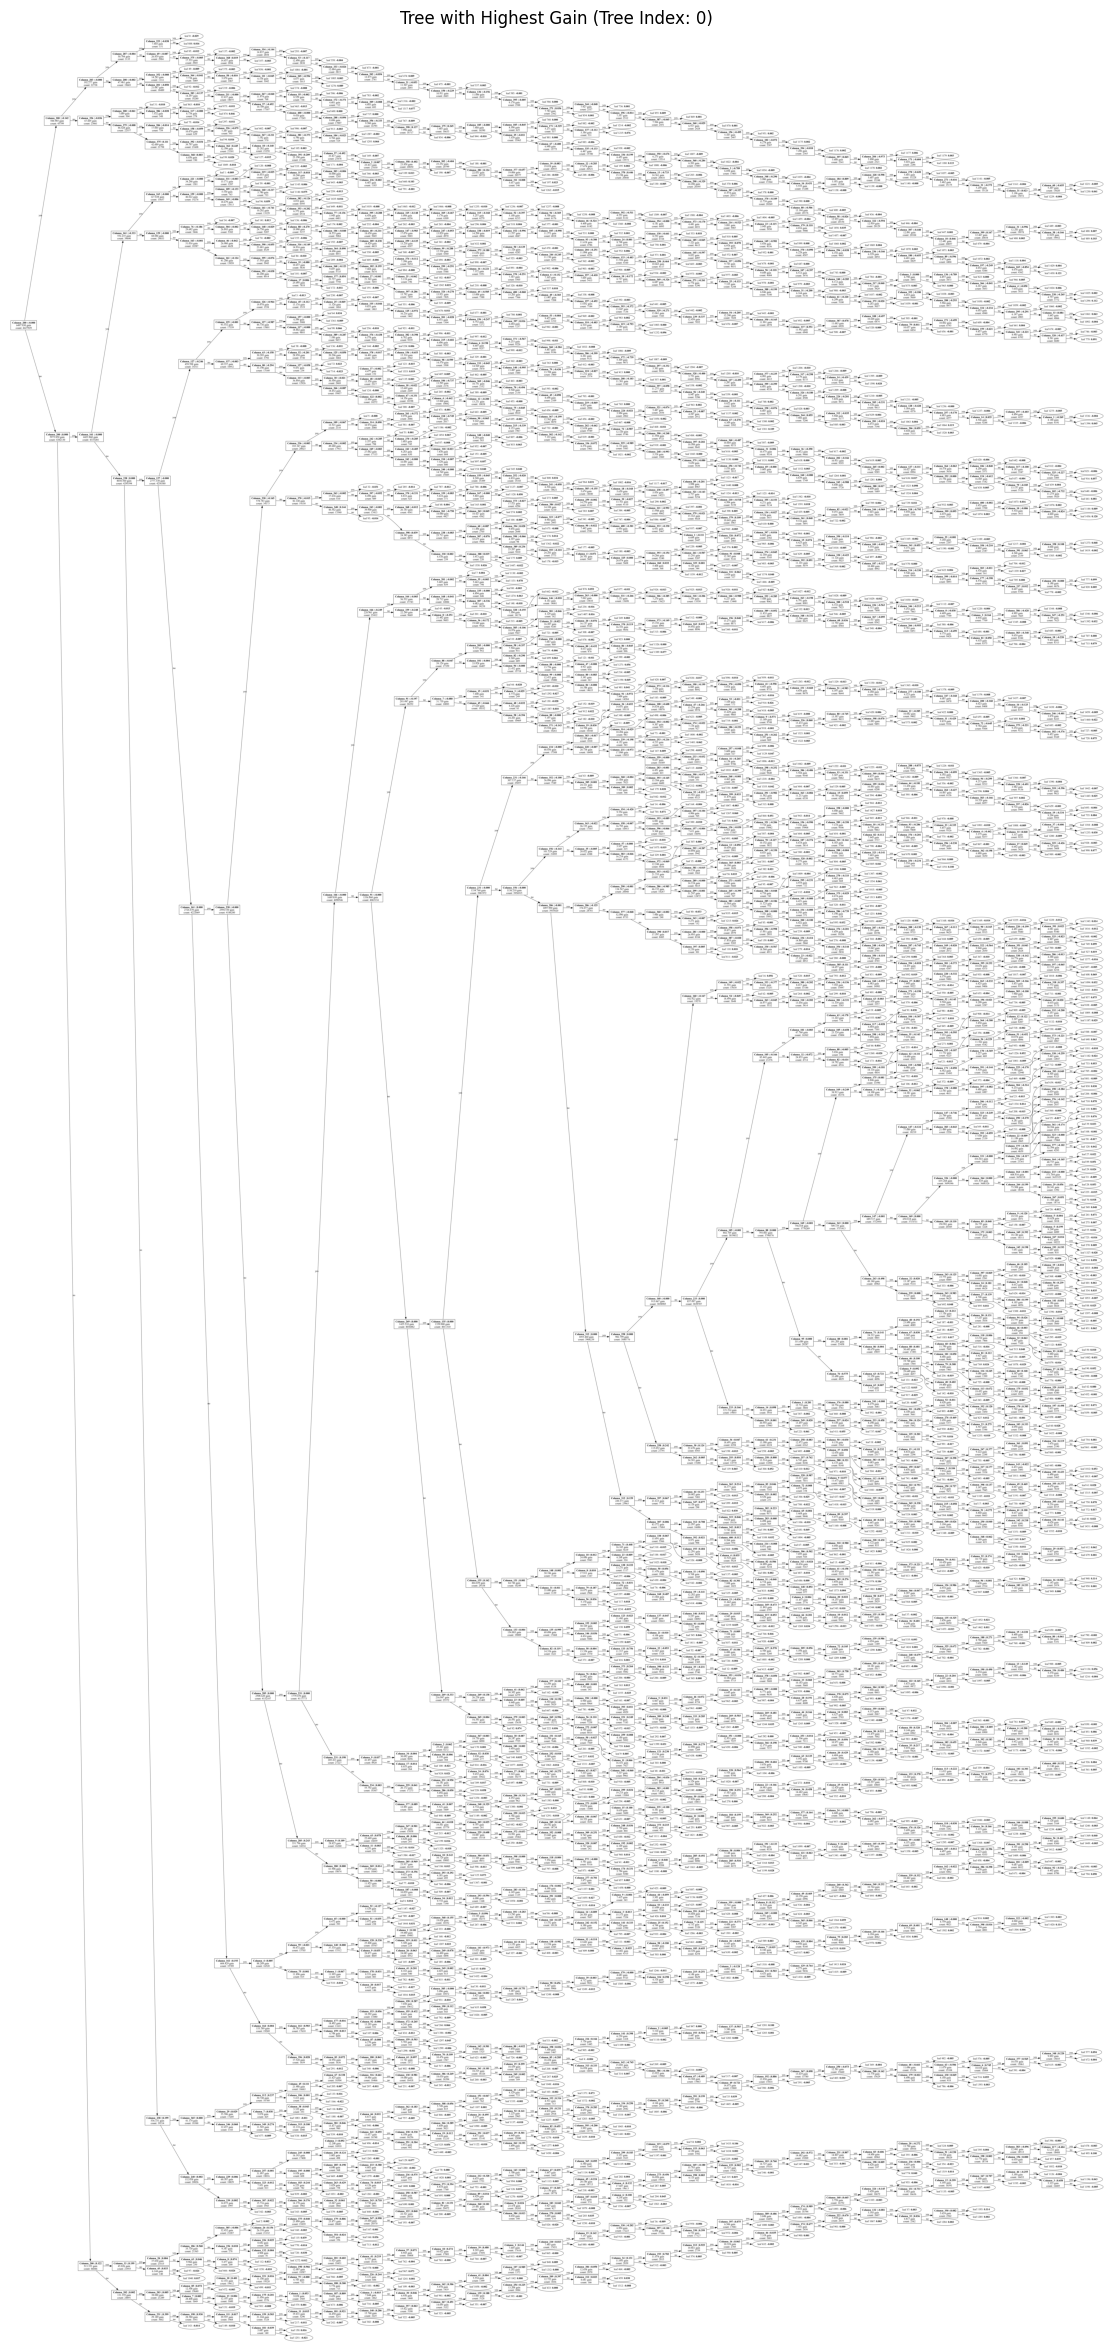

In [15]:
# Plot the tree with the highest gain
ax = lgb.plot_tree(model, tree_index=highest_gain_tree_index, figsize=(40, 30), show_info=['split_gain', 'internal_count'])

plt.title(f"Tree with Highest Gain (Tree Index: {highest_gain_tree_index})")
plt.savefig("tree_visualization_highest_gain.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

In [16]:
# Create a Graphviz visualization for the highest gain tree
graph = create_tree_digraph(model, 
                            tree_index=highest_gain_tree_index, 
                            show_info=['split_gain', 'internal_count'])

# Save as a PDF for high-resolution output
graph.render("tree_visualization_highest_gain_graphviz", format="pdf", cleanup=True)

# Open the PDF in a viewer
graph.view()

print("Graphviz visualization of the highest gain tree saved as 'tree_visualization_highest_gain_graphviz.pdf'.")


Graphviz visualization of the highest gain tree saved as 'highest_gain_tree_graph.pdf'.
